In [1]:
#Importing Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [2]:
#Importing image data
train_dir = r".\Downloads\archive (3)\chest_xray\chest_xray\train"
val_dir   = r".\Downloads\archive (3)\chest_xray\chest_xray\val"
test_dir  = r".\Downloads\archive (3)\chest_xray\chest_xray\test"

In [3]:
#Data Loading
img_height = 150
img_width = 150
batch_size = 32
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,        # randomly rotate images
    width_shift_range=0.2,    # shift images horizontally
    height_shift_range=0.2,   # shift images vertically
    shear_range=0.2,          # shear transformation
    zoom_range=0.2,           # zoom in/out
    horizontal_flip=True,     # flip images horizontally
    fill_mode='nearest'       # fill in new pixels after transformations
)

test_datagen  = ImageDataGenerator(rescale=1/255.0)
val_datagen   = ImageDataGenerator(rescale=1/255.0)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [4]:
#Building the CNN Model
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())
model.add(Dropout(0.25))  # Helps reduce overfitting

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Binary classification


C:\Users\revat\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#compiling the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Stop training if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [7]:
#Training the Model
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    validation_data=val_data,
    validation_steps=val_data.samples // batch_size,
    epochs=50,  # Can increase; early stopping will handle stopping
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8181 - loss: 0.6544 - val_accuracy: 0.5000 - val_loss: 24.8705 - learning_rate: 0.0010
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 159s 979ms/step - accuracy: 0.8662 - loss: 0.3445 - val_accuracy: 0.5000 - val_loss: 10.6860 - learning_rate: 0.0010
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 645s 4s/step - accuracy: 0.8783 - loss: 0.3144 - val_accuracy: 0.5000 - val_loss: 4.8741 - learning_rate: 0.0010
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8767 - loss: 0.3453 - val_accuracy: 0.6250 - val_loss: 3.5630 - learning_rate: 0.0010
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.8788 - loss: 0.3089 - val_accuracy: 0.8125 - val_loss: 0.4802 - learning_rate: 0.0010
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8928 - loss: 0.2723 - val_accuracy: 0.7500 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8934 - los

In [8]:
#Evaluating on test data
test_loss, test_acc = model.evaluate(test_data, steps=test_data.samples // batch_size)
print("Test Accuracy:", test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8372 - loss: 0.3766
Test Accuracy: 0.8371710777282715


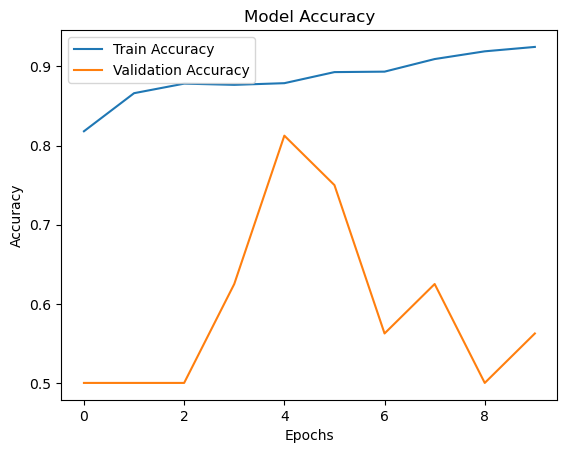

In [9]:
#Plotting Training & Validation Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 654ms/step
Confusion Matrix:
 [[107 127]
 [152 238]]


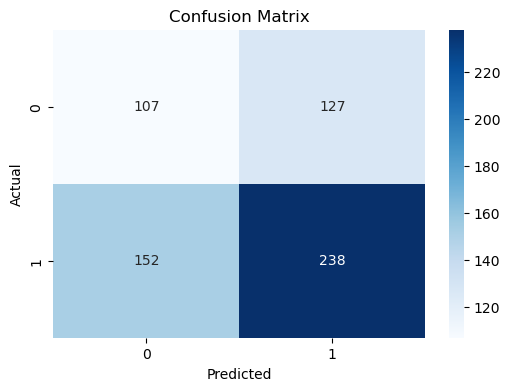

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.41      0.46      0.43       234
   PNEUMONIA       0.65      0.61      0.63       390

    accuracy                           0.55       624
   macro avg       0.53      0.53      0.53       624
weighted avg       0.56      0.55      0.56       624



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# Get true labels and predictions
# Reset the test_data generator to start from the beginning
test_data.reset()

# Predict probabilities
y_pred_prob = model.predict(test_data, steps=test_data.samples // batch_size + 1)
# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report: Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=test_data.class_indices.keys())
print("Classification Report:\n", report)


In [11]:
'''This saves the model in the new native Keras format.we can load it later with:
from tensorflow.keras.models import load_model
model = load_model("pneumonia_model.keras") '''

model.save("pneumonia_model.keras")

In [36]:
from tensorflow.keras.models import load_model
model = load_model("pneumonia_model.keras")

In [38]:
import tensorflow as tf
inp = tf.keras.Input(shape=(150,150,3))
x = inp
for layer in model.layers[:-1]:
    x = layer(x)

feature_extractor = tf.keras.Model(inputs=inp, outputs=x)

In [40]:
test_data.reset()
test_features = feature_extractor.predict(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 659ms/step


In [42]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(test_features)

C:\Users\revat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [44]:
true_labels = test_data.classes
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(true_labels, clusters)
print("Clustering ARI:", ari)

Clustering ARI: 0.008290366244296325
